In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler


# Step 1: Load your CSV
df = pd.read_csv(r"C:\Users\apagano\from_Github\Python_notebooks_AI_ML_ETL\Ukraine Behavioral Data USFCA\Survey Data Ukraine USFCA 2_2026.csv")  # replace with your file path

print(df.columns.tolist())  # Check column names to ensure they are correct

In [3]:


# Step 1: Load your CSV
df = pd.read_csv(r"C:\Users\apagano\from_Github\Python_notebooks_AI_ML_ETL\Ukraine Behavioral Data USFCA\Survey Data Ukraine USFCA 2_2026.csv")  # replace with your file path

print(df.columns.tolist())  # Check column names to ensure they are correct

['ResponseID', 'IPAddress', 'StartDate', 'EndDate', 'Finished', 'response_id', 'assignment_id', 'completion_code', 'Q_RecaptchaScore', 'Q_RelevantIDDuplicate', 'Q_RelevantIDDuplicateScore', 'Q_RelevantIDFraudScore', 'manuallyIDduplicateIP', 'Survey, Treatment, Prosocial', 'Q_TotalDuration', 'StroopPractice1_Time', 'StroopPractice1_Score', 'StroopPractice2_Time', 'StroopPractice2_Score', 'StroopBaseline_Time', 'StroopBaseline_Score', 'StroopEmotional_Time', 'StroopEmotional_Score', 'StroopEmotionalCompetitive_Time', 'StroopEmotionalCompetitive_Score', 'StroopEmotionalChoice_Time', 'StroopEmotionalChoice_Score', 'Surveys, Control, Prosocial', 'StroopControl_Time', 'StroopControl_Score', 'StroopControlCompetitive_Time', 'StroopControlCompetitive_Score', 'StroopControlChoice_Time', 'StroopControlChoice_Score', 'Treatment, Prosocial, Surveys', 'Control, Prosocial, Surveys', 'Prosocial, Treatment, Surveys', 'Prosocial, Control, Surveys', 'completed', 'Anxiety Score', 'Depression Score', 'Anx

In [4]:


# Step 2: Convert the entire dataframe
# NaN -> 0, everything else -> 1

df_War_Experience = df[['War Experience_1', 'War Experience_2', 'War Experience_3', 'War Experience_4', 'War Experience_5', 'War Experience_6', 'War Experience_7', 'War Experience_8', 'War Experience_9', 'War Experience_10', 'War Experience_11', 'War Experience_12', 'War Experience_13']]
df_War_Experience = df_War_Experience.notna().astype(int)

print(df_War_Experience['War Experience_1'].describe())
print(df_War_Experience['War Experience_2'].describe())
print(df_War_Experience['War Experience_3'].describe())
print(df_War_Experience['War Experience_4'].describe())
print(df_War_Experience['War Experience_5'].describe())
print(df_War_Experience['War Experience_6'].describe())
print(df_War_Experience['War Experience_7'].describe())
print(df_War_Experience['War Experience_8'].describe())
print(df_War_Experience['War Experience_9'].describe())
print(df_War_Experience['War Experience_10'].describe())
print(df_War_Experience['War Experience_11'].describe())
print(df_War_Experience['War Experience_12'].describe())
print(df_War_Experience['War Experience_13'].describe())

# Step 4: Check the result

df_War_Experience = df_War_Experience[['War Experience_1', 'War Experience_2', 'War Experience_7', 'War Experience_11', 'War Experience_12', 'War Experience_13']]


count    771.000000
mean       0.127108
std        0.333310
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: War Experience_1, dtype: float64
count    771.000000
mean       0.443580
std        0.497129
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: War Experience_2, dtype: float64
count    771.000000
mean       0.047990
std        0.213883
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: War Experience_3, dtype: float64
count    771.000000
mean       0.023346
std        0.151099
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: War Experience_4, dtype: float64
count    771.000000
mean       0.011673
std        0.107480
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: War Experience_5, dtype: float64
count

Eigenvalues:
 [2.89673791e+00 1.72745735e+00 3.55910660e-01 1.98940820e-02
 2.68214970e-17]

Eigenvectors (columns correspond to eigenvalues):
              0         1         2         3             4
var1  0.297030  0.642791 -0.248563  0.660916  4.120066e-15
var2  0.525236 -0.073704 -0.726163 -0.437472 -3.251840e-15
var3 -0.563168  0.108758 -0.413457 -0.008172  7.071068e-01
var4  0.563168 -0.108758  0.413457  0.008172  7.071068e-01
var5  0.039794 -0.746814 -0.262697  0.609652  3.853717e-15


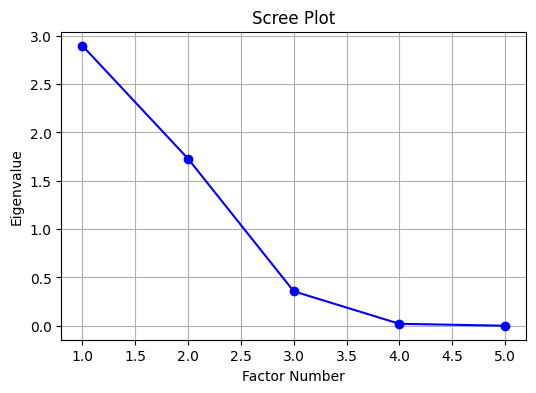


Factor Loadings:
        Factor1       Factor2
var1  0.327327 -9.295045e-01
var2  0.763763 -1.578654e-01
var3 -1.000000 -4.916379e-12
var4  1.000000  4.916416e-12
var5  0.166667  8.772999e-01

Factor Scores:
 [[-0.81649658 -0.0817148 ]
 [ 1.22474487 -0.73827198]
 [-0.81649658  1.4106651 ]
 [ 1.22474487  0.73827198]
 [-0.81649658 -1.3289503 ]]


In [35]:





# Example data
data = pd.DataFrame({
    'var1': [4, 5, 3, 4, 5],
    'var2': [2, 3, 2, 4, 3],
    'var3': [5, 4, 5, 4, 5],
    'var4': [1, 2, 1, 2, 1],
    'var5': [3, 3, 4, 4, 3]
})

def proc_factor_sklearn_with_eigen(data, n_factors=2):
    # --- Standardize data ---
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    # --- Correlation matrix ---
    corr_matrix = np.corrcoef(data_scaled, rowvar=False)
    
    # --- Eigen decomposition ---
    eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)
    
    # Sort eigenvalues (and eigenvectors) descending
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    print("Eigenvalues:\n", eigenvalues)
    print("\nEigenvectors (columns correspond to eigenvalues):\n", pd.DataFrame(eigenvectors, index=data.columns))
    
    # --- Scree plot ---
    plt.figure(figsize=(6,4))
    plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='blue')
    plt.title('Scree Plot')
    plt.xlabel('Factor Number')
    plt.ylabel('Eigenvalue')
    plt.grid(True)
    plt.show()
    
    # --- Factor Analysis ---
    fa = FactorAnalysis(n_components=n_factors, random_state=42)
    factors = fa.fit_transform(data_scaled)
    
    # Factor loadings
    loadings = pd.DataFrame(fa.components_.T, index=data.columns,
                            columns=[f'Factor{i+1}' for i in range(n_factors)])
    print("\nFactor Loadings:\n", loadings)
    
    
    print("\nFactor Scores:\n", factors)

# Run the function
proc_factor_sklearn_with_eigen(data, n_factors=2)


Eigenvalues:
 [1.9449961  1.11920041 0.87275649 0.7919464  0.6997232  0.57137739]

Eigenvectors (columns correspond to eigenvalues):
                           0         1         2         3         4         5
War Experience_1  -0.245737 -0.678401 -0.339266 -0.369191  0.473684  0.060044
War Experience_2  -0.436460  0.207786  0.627490 -0.278721  0.241710  0.486287
War Experience_7  -0.461081 -0.274421 -0.029157 -0.205921 -0.817305  0.029261
War Experience_11 -0.398709  0.351709 -0.621368  0.341202  0.059497  0.459647
War Experience_12 -0.477481  0.416175 -0.100445 -0.249943  0.170950 -0.705001
War Experience_13 -0.386735 -0.352689  0.306786  0.751478  0.128249 -0.225304


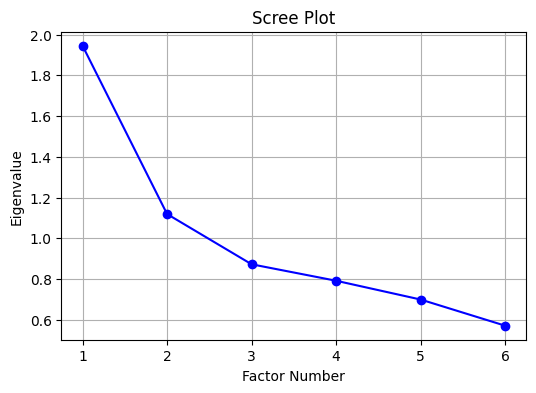


Factor Loadings:
                     Factor1   Factor2
War Experience_1   0.146096  0.358925
War Experience_2   0.446055  0.090850
War Experience_7   0.414207  0.406483
War Experience_11  0.428156 -0.004833
War Experience_12  0.782600 -0.218119
War Experience_13  0.280345  0.376686

Factor Scores:
 [[-0.63519515 -0.13801507]
 [-0.63519515 -0.13801507]
 [ 0.82784462 -0.99778078]
 ...
 [-0.32509574 -0.00484467]
 [-0.63519515 -0.13801507]
 [-0.32509574 -0.00484467]]


In [36]:
proc_factor_sklearn_with_eigen(df_War_Experience, n_factors=2)

In [ ]:

def evaluate_factor_model(data, n_factors=2):

    # ----------------------------
    # Standardize Data
    # ----------------------------
    scaler = StandardScaler()
    X = scaler.fit_transform(data)
    n_samples, n_vars = X.shape

    # ----------------------------
    # Fit Factor Model (ML)
    # ----------------------------
    fa = FactorAnalysis(n_components=n_factors, random_state=42)
    fa.fit(X)

    loadings = fa.components_.T
    loadings_df = pd.DataFrame(
        loadings,
        index=data.columns,
        columns=[f'Factor{i+1}' for i in range(n_factors)]
    )

    print("\nFACTOR LOADINGS\n")
    print(loadings_df)

    # ----------------------------
    # Variance Explained
    # ----------------------------
    ss_loadings = np.sum(loadings**2, axis=0)
    total_variance = n_vars
    prop_var = ss_loadings / total_variance
    cum_var = np.cumsum(prop_var)

    variance_table = pd.DataFrame({
        "SS Loadings": ss_loadings,
        "Proportion Var": prop_var,
        "Cumulative Var": cum_var
    }, index=[f'Factor{i+1}' for i in range(n_factors)])

    print("\nVARIANCE EXPLAINED\n")
    print(variance_table)

    # ----------------------------
    # Communalities & Uniqueness
    # ----------------------------
    communalities = np.sum(loadings**2, axis=1)
    uniqueness = 1 - communalities

    comm_table = pd.DataFrame({
        "Communality": communalities,
        "Uniqueness": uniqueness
    }, index=data.columns)

    print("\nCOMMUNALITIES\n")
    print(comm_table)

    # ----------------------------
    # Log-Likelihood
    # ----------------------------
    log_likelihood = fa.score(X) * n_samples
    print("\nLOG-LIKELIHOOD:", log_likelihood)

    # ----------------------------
    # AIC & BIC
    # ----------------------------
    # Number of parameters
    k = n_vars * n_factors + n_vars  # loadings + unique variances

    AIC = -2 * log_likelihood + 2 * k
    BIC = -2 * log_likelihood + k * np.log(n_samples)

    print("\nAIC:", AIC)
    print("BIC:", BIC)

    # ----------------------------
    # Residual Correlation Matrix
    # ----------------------------
    corr_matrix = np.corrcoef(X, rowvar=False)

    reproduced_corr = loadings @ loadings.T + np.diag(fa.noise_variance_)
    residual = corr_matrix - reproduced_corr

    residual_df = pd.DataFrame(residual, 
                               index=data.columns, 
                               columns=data.columns)

    print("\nRESIDUAL CORRELATION MATRIX\n")
    print(residual_df)

    return {
        "loadings": loadings_df,
        "variance_table": variance_table,
        "communalities": comm_table,
        "log_likelihood": log_likelihood,
        "AIC": AIC,
        "BIC": BIC,
        "residual_matrix": residual_df
    }


In [6]:
evaluate_factor_model(df_War_Experience, n_factors=2)


FACTOR LOADINGS

                    Factor1   Factor2
War Experience_1   0.146096  0.358925
War Experience_2   0.446055  0.090850
War Experience_7   0.414207  0.406483
War Experience_11  0.428156 -0.004833
War Experience_12  0.782600 -0.218119
War Experience_13  0.280345  0.376686

VARIANCE EXPLAINED

         SS Loadings  Proportion Var  Cumulative Var
Factor1     1.266250        0.211042        0.211042
Factor2     0.491801        0.081967        0.293009

COMMUNALITIES

                   Communality  Uniqueness
War Experience_1      0.150171    0.849829
War Experience_2      0.207219    0.792781
War Experience_7      0.336796    0.663204
War Experience_11     0.183341    0.816659
War Experience_12     0.660038    0.339962
War Experience_13     0.220486    0.779514

LOG-LIKELIHOOD: -6374.704379159465

AIC: 12785.40875831893
BIC: 12869.06714904307

RESIDUAL CORRELATION MATRIX

                   War Experience_1  War Experience_2  War Experience_7  \
War Experience_1           0.00

{'loadings':                     Factor1   Factor2
 War Experience_1   0.146096  0.358925
 War Experience_2   0.446055  0.090850
 War Experience_7   0.414207  0.406483
 War Experience_11  0.428156 -0.004833
 War Experience_12  0.782600 -0.218119
 War Experience_13  0.280345  0.376686,
 'variance_table':          SS Loadings  Proportion Var  Cumulative Var
 Factor1     1.266250        0.211042        0.211042
 Factor2     0.491801        0.081967        0.293009,
 'communalities':                    Communality  Uniqueness
 War Experience_1      0.150171    0.849829
 War Experience_2      0.207219    0.792781
 War Experience_7      0.336796    0.663204
 War Experience_11     0.183341    0.816659
 War Experience_12     0.660038    0.339962
 War Experience_13     0.220486    0.779514,
 'log_likelihood': np.float64(-6374.704379159465),
 'AIC': np.float64(12785.40875831893),
 'BIC': np.float64(12869.06714904307),
 'residual_matrix':                    War Experience_1  War Experience_2  War